## 1. Setup and Configuration

In [1]:
import os
import sys
import yaml
from pathlib import Path

# Direct path setup
PROJECT_ROOT_PATH = "./"
project_root = Path(PROJECT_ROOT_PATH)

if not project_root.exists():
    raise RuntimeError(f"Project root not found at: {project_root}")

if not (project_root / 'text_simulation').exists():
    raise RuntimeError(f"'text_simulation' directory not found in: {project_root}")

if not (project_root / 'evaluation').exists():
    raise RuntimeError(f"'evaluation' directory not found in: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"✅ Project root: {project_root}")
print(f"Current directory: {Path.cwd()}")
print(f"Python path configured: {sys.path[0]}")

✅ Project root: .
Current directory: d:\simulation\sim
Python path configured: .


## 2. Download Dataset

First, we'll download the Twin-2K-500 dataset from Hugging Face.

In [2]:
print("=" * 60)
print("Step 1: Download Dataset")
print("=" * 60)

data_dir = project_root / "data"
if (data_dir / "mega_persona_json" / "mega_persona").exists():
    print("✅ Dataset already downloaded")
else:
    print("Downloading dataset...")
    # Save current directory
    original_cwd = Path.cwd()
    
    try:
        # Change to project root for download
        os.chdir(project_root)
        
        # Import and run the download function directly
        import download_dataset
        download_dataset.main()
        print("✅ Dataset downloaded successfully")
    except Exception as e:
        print(f"❌ Error downloading dataset: {e}")
    finally:
        # Restore original directory
        os.chdir(original_cwd)

Step 1: Download Dataset
✅ Dataset already downloaded


## 3. Create Persona Facets

Convert the JSON persona data into persona facets for LLM.

In [3]:
print("=" * 60)
print("Step 2: Create Persona Facets")
print("=" * 60)

import sys
import subprocess

if (project_root / "text_simulation" / "persona_facets").exists():
    print("✅ Persona facets already exist")
else:
    env = os.environ.copy()
    env['PYTHONPATH'] = str(project_root / 'text_simulation') + os.pathsep + env.get('PYTHONPATH', '')

    result = subprocess.run(
        [sys.executable, str(project_root / "text_simulation" / "create_persona_facets.py")],
        cwd=str(project_root),
        capture_output=True,
        env=env,
        text=True
    )

    print(result.stdout)

Step 2: Create Persona Facets
✅ Persona facets already exist


## 4. Create Simulation Input

Process the survey questions into a format suitable for the simulation.

In [4]:
print("=" * 60)
print("Step 3: Create Simulation Input")
print("=" * 60)

import subprocess

input_dirs = [project_root / "text_simulation" / "simulation_input_one_shot",
              project_root / "text_simulation" / "simulation_input_multi_shot"]

scripts = ["create_question_one_shot.py", "create_question_multi_shot.py"]

for input_dir, script in zip(input_dirs, scripts):
    if not input_dir.exists():
        env = os.environ.copy()
        env['PYTHONPATH'] = str(project_root / 'text_simulation') + os.pathsep + env.get('PYTHONPATH', '')

        result = subprocess.run(
            [sys.executable, str(project_root / "text_simulation" / script)],
            cwd=str(project_root),
            capture_output=True,
            env=env,
            text=True
        )

        print(result.stdout)

Step 3: Create Simulation Input


## 5. Run LLM Simulations

Now we'll run the actual LLM simulations. This will use the Model Provider API to generate responses.

In [5]:
from dotenv import load_dotenv

load_dotenv(project_root / '.env')

base_dir = project_root / "text_simulation"

try:
    with open(project_root / "text_simulation" / "config.yaml", "r") as f:
        config = yaml.safe_load(f)

    config['max_personas'] = 5
    config['simulation_type'] = "multi_shot" # one_shot / multi_shot
    config['model_identifier'] = "deepseek-chat"
    config['temperature'] = 1.0
    config['semaphore'] = 100
    config['input_dir'] = str(base_dir / f"simulation_input_{config['simulation_type']}")
    config['persona_dir'] = str(base_dir / "persona_facets")
    config['output_dir'] =  str(base_dir / f"simulation_output_{config['simulation_type']}" / config['model_identifier'].split('/')[-1])
    config['save_path'] = os.path.join(config['output_dir'], f"{config['model_identifier']}.db")

    with open(project_root / "text_simulation" / "config.yaml", "w") as f:
        yaml.safe_dump(config, f, default_flow_style=False)

except Exception as e:
    print(f"Error updating config: {e}")

In [6]:
print("=" * 60)
print("Step 4: Run LLM Simulations")
print("=" * 60)

import subprocess

env = os.environ.copy()
env['PYTHONPATH'] = str(project_root) + os.pathsep + str(project_root / 'text_simulation') + os.pathsep + env.get('PYTHONPATH', '')

if config['simulation_type'] == "one_shot":
    script = "simulate_persona_one_shot.py"
else:
    script = "simulate_persona_multi_shot.py"

process = subprocess.Popen(
    [
        sys.executable, 
        str(project_root / "text_simulation" / script),
        "--config", str(project_root / "text_simulation" / "config.yaml")
    ],
    cwd=str(project_root),
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

try:
    for line in process.stdout:
        print(line.rstrip())
    process.wait()
    if process.returncode == 0:
        print("\n✅ Simulations completed successfully")
    else:
        print(f"\n❌ Error running simulations (exit code: {process.returncode})")
except KeyboardInterrupt:
    print("\n⚠️  Simulation interrupted by user")
    process.terminate()
    process.wait()

Step 4: Run LLM Simulations
Start simulating...

Simulating persona: 100%|██████████| 5/5 [01:55<00:00, 23.06s/it]

✅ Simulations completed successfully


# 6. Postprocess simulation output

In [7]:
print("=" * 60)
print("Step 5: Postprocess Simulation Output")
print("=" * 60)

import subprocess

env = os.environ.copy()
env['PYTHONPATH'] = str(project_root / 'text_simulation') + os.pathsep + env.get('PYTHONPATH', '')

result = subprocess.run(
    [sys.executable, str(project_root / "text_simulation" / "postprocess_llm_response.py"),
    "--simulation_output_dir", config['output_dir']],
    cwd=str(project_root),
    capture_output=True,
    env=env,
    text=True
)

print(result.stdout)

Step 5: Postprocess Simulation Output
Updated answer block JSONs will be saved to: text_simulation\simulation_output_multi_shot\deepseek-chat\answer_blocks_llm_imputed
Found 5 valid simulation outputs to process.
Postprocessing complete. Successful updates: 5, Failed/Skipped: 0.



## 7. Convert JSON to CSV for Evaluation

Convert the JSON answer blocks to CSV format for evaluation purposes.

In [8]:
print("=" * 60)
print("Step 6: Convert JSON to CSV for Evaluation")
print("=" * 60)

eval_config = {
    "trial_dir": config['output_dir'],
    "model_name": config['model_identifier'],
    "max_personas": config['max_personas'],
    "waves": {
        "wave1_3": {
            "input_pattern": "data/mega_persona_json/answer_blocks/pid_{pid}_wave4_Q_wave1_3_A.json",
            "output_csv": "${trial_dir}/csv_comparison/responses_wave1_3.csv",
            "output_csv_formatted": "${trial_dir}/csv_comparison/csv_formatted/responses_wave1_3_formatted.csv",
            "output_csv_labeled": "${trial_dir}/csv_comparison/csv_formatted_label/responses_wave1_3_label_formatted.csv"
        },
        "wave4": {
            "input_pattern": "data/mega_persona_json/answer_blocks/pid_{pid}_wave4_Q_wave4_A.json",
            "output_csv": "${trial_dir}/csv_comparison/responses_wave4.csv",
            "output_csv_formatted": "${trial_dir}/csv_comparison/csv_formatted/responses_wave4_formatted.csv",
            "output_csv_labeled": "${trial_dir}/csv_comparison/csv_formatted_label/responses_wave4_label_formatted.csv"
        },
        "llm_imputed": {
            "input_pattern": "${trial_dir}/answer_blocks_llm_imputed/pid_{pid}_wave4_Q_wave4_A.json",
            "output_csv": "${trial_dir}/csv_comparison/responses_llm_imputed.csv",
            "output_csv_formatted": "${trial_dir}/csv_comparison/csv_formatted/responses_llm_imputed_formatted.csv",
            "output_csv_labeled": "${trial_dir}/csv_comparison/csv_formatted_label/responses_llm_imputed_label_formatted.csv"
        }
    },
    "benchmark_csv": "data/wave_csv/wave_4_numbers_anonymized.csv",
    "column_mapping": "evaluation/column_mapping.csv",
    "save_question_mapping": True,
    "question_mapping_output": "${trial_dir}/csv_comparison/question_mapping.csv",
    "generate_randdollar_breakdown": True,
    "randdollar_output": "${trial_dir}/csv_comparison/randdollar_breakdown.csv"
}

# Write temporary config file
temp_eval_config = project_root / "temp_eval_config.yaml"
with open(temp_eval_config, 'w') as f:
    yaml.dump(eval_config, f)

print("Converting JSON results to CSV format...")

# Run json2csv conversion
result = subprocess.run(
    [sys.executable, "evaluation/json2csv.py", "--config", str(temp_eval_config), "--all", "--verbose"],
    cwd=str(project_root),
    capture_output=True,
    text=True
)

print(result.stdout)

if temp_eval_config.exists():
    temp_eval_config.unlink()

Step 6: Convert JSON to CSV for Evaluation
Converting JSON results to CSV format...



## 8. MAD Accuracy Evaluation

Run Mean Absolute Difference (MAD) accuracy evaluation to compare simulated responses with ground truth.

Step 7: MAD Accuracy Evaluation
Computing MAD accuracy metrics...
✅ MAD evaluation completed successfully
   Results saved to: text_simulation\simulation_output_multi_shot\deepseek-chat\accuracy_evaluation
   ✅ Excel summary: mad_accuracy_summary.xlsx
   ✅ Accuracy plot: accuracy_dist.png


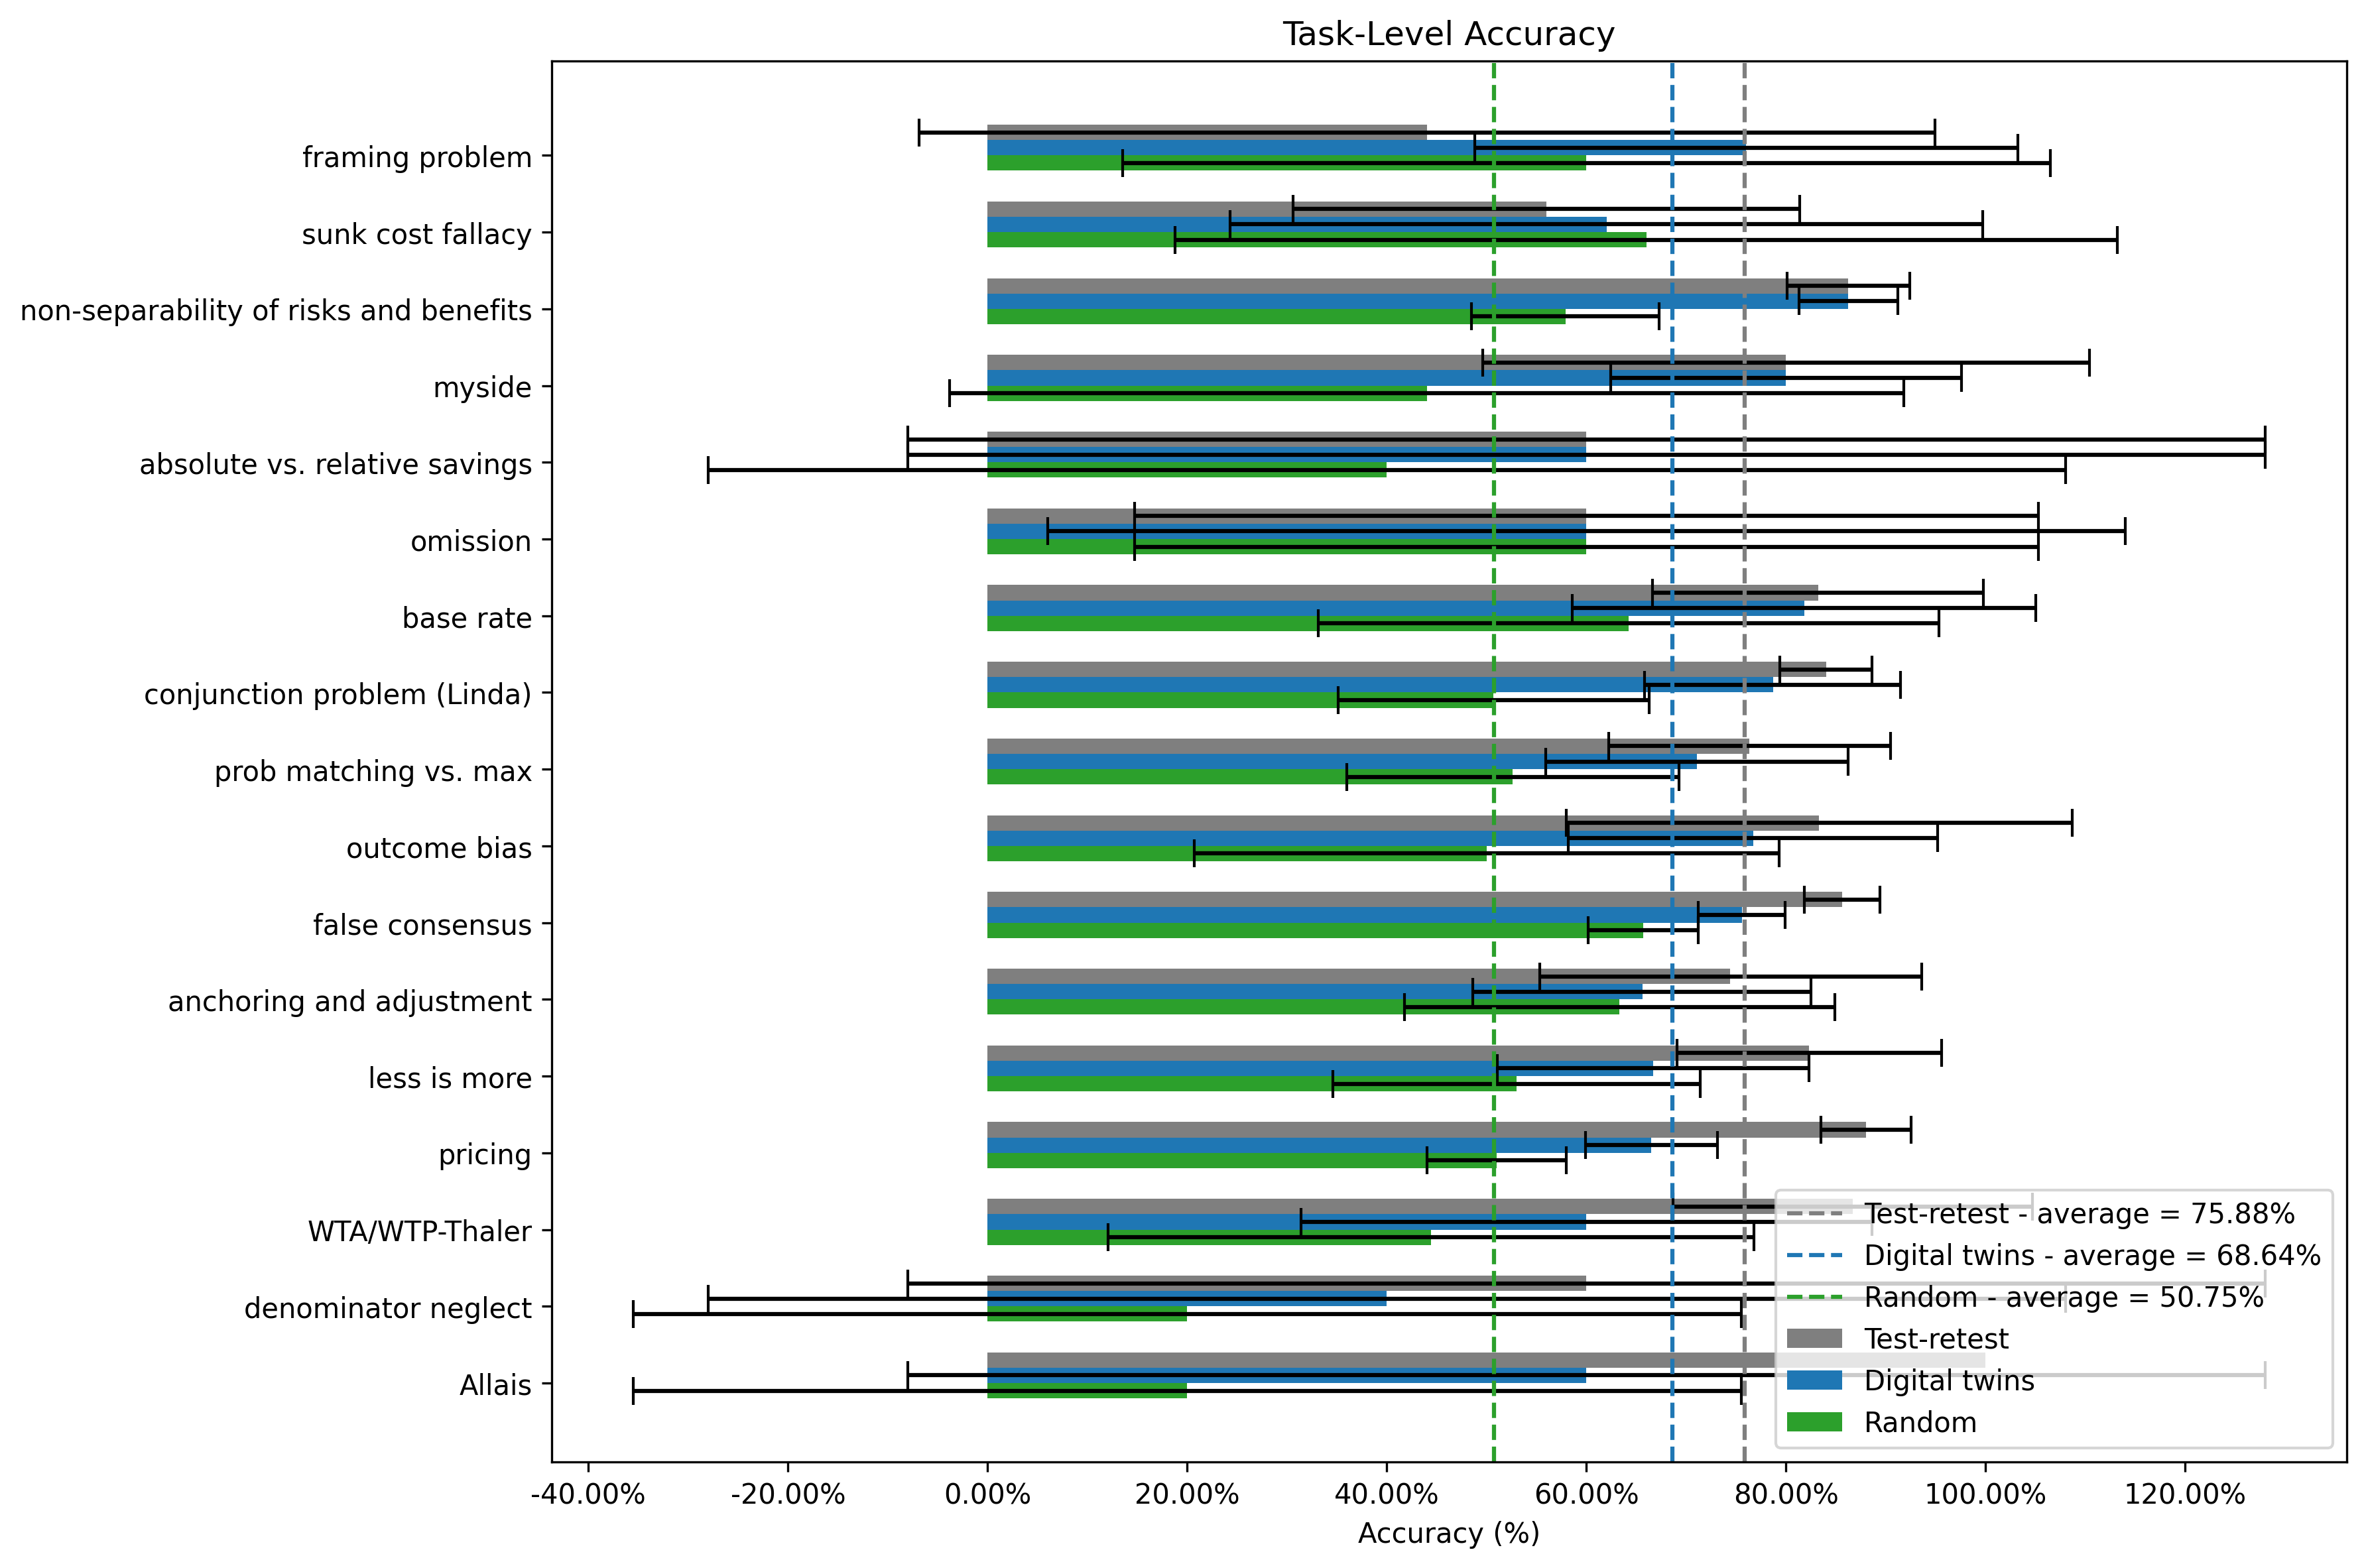

In [9]:
print("=" * 60)
print("Step 7: MAD Accuracy Evaluation")
print("=" * 60)

# Set up paths for MAD evaluation
trial_dir = Path(config['output_dir'])
csv_dir = trial_dir / "csv_comparison" / "csv_formatted"
output_dir = trial_dir / "accuracy_evaluation"
output_dir.mkdir(parents=True, exist_ok=True)

plot_title = config['model_identifier']

# Create MAD evaluation config
mad_config = {
    "trial_dir": str(trial_dir),
    "csv_dir": str(csv_dir),
    "output_dir": str(output_dir),
    "output_excel_filename": "mad_accuracy_summary.xlsx",
    "output_plot_filename": "accuracy_dist.png",
    "plot_title": f"Digital Twin Simulation - {plot_title}"
}

# Write temporary config file
temp_mad_config = project_root / "temp_mad_config.yaml"
with open(temp_mad_config, 'w') as f:
    yaml.dump(mad_config, f)

print("Computing MAD accuracy metrics...")

# Check if required CSV files exist
required_files = ["responses_wave1_3_formatted.csv", "responses_wave4_formatted.csv", "responses_llm_imputed_formatted.csv"]
missing_files = [f for f in required_files if not (csv_dir / f).exists()]

if missing_files:
    print(f"⚠️  Missing required CSV files: {missing_files}")
    print("   Skipping MAD evaluation...")
else:
    # Run MAD evaluation
    result = subprocess.run(
        [sys.executable, "evaluation/mad_accuracy_evaluation.py", "--config", str(temp_mad_config), "--verbose"],
        cwd=str(project_root),
        capture_output=True,
        text=True
    )

    if result.returncode == 0:
        print("✅ MAD evaluation completed successfully")
        print(f"   Results saved to: {output_dir}")
        
        # Check outputs
        excel_file = output_dir / "mad_accuracy_summary.xlsx"
        plot_file = output_dir / "accuracy_dist.png"
        
        if excel_file.exists():
            print(f"   ✅ Excel summary: {excel_file.name}")
        if plot_file.exists():
            print(f"   ✅ Accuracy plot: {plot_file.name}")
            
            # Try to display the plot if in notebook environment
            try:
                from IPython.display import Image, display
                display(Image(str(plot_file)))
            except:
                print("   (Plot saved but cannot display inline)")
    else:
        print(f"⚠️  MAD evaluation encountered issues")
        print(f"   Error: {result.stderr[:500]}...")

# Clean up temp config
if temp_mad_config.exists():
    temp_mad_config.unlink()

## 9. Within-Between Subjects Analysis

This analysis examines behavioral economics experiments across different waves.

In [28]:
print("=" * 60)
print("Step 8: Within-Between Subjects Analysis")
print("=" * 60)

# Import the analysis classes directly
from evaluation.within_between_subjects import (
    DataLoader, ExcelWriter, BaseRateAnalysis, OutcomeBiasAnalysis,
    FalseConsensusAnalysis, SunkCostAnalysis, AllaisProblemAnalysis,
    NonseparabilityAnalysis, FramingAnalysis, LindaProblemAnalysis,
    AnchoringAnalysis, RelativeSavingsAnalysis, MysideBiasAnalysis,
    OmissionBiasAnalysis, LessIsMoreAnalysis, ThalerProblemAnalysis,
    ProbabilityMatchingAnalysis, DenominatorNeglectAnalysis
)

print("Running within-between subjects analysis...")
print("This analysis examines behavioral economics experiments across waves.")

# Save current directory and change to project root for the analysis
original_cwd = Path.cwd()
os.chdir(project_root)

try:
    # Set up data loader (now with correct relative paths from project root)
    trial_dir_str = str(trial_dir.relative_to(project_root))
    data_loader = DataLoader(trial_dir_str)
    
    # Get common IDs (respondents who completed all 4 waves)
    try:
        common_ids = data_loader.get_common_ids()
        print(f"\n✅ Found {len(common_ids)} respondents who completed all 4 waves")
    except Exception as e:
        print(f"⚠️  Error finding common respondents: {e}")
        print("   This analysis requires the full dataset with all waves")
        common_ids = set()
    
    if len(common_ids) > 0:
        # Load data for each wave
        print("\nLoading wave data...")
        try:
            data = {
                "wave1": data_loader.load_wave_data("wave1", common_ids),
                "wave2": data_loader.load_wave_data("wave2", common_ids),
                "wave3": data_loader.load_wave_data("wave3", common_ids),
                "wave4": data_loader.load_wave_data("wave4", common_ids),
                "LLM": data_loader.load_wave_data("LLM", common_ids)
            }
            
            for wave, df in data.items():
                if df is not None and not df.empty:
                    print(f"   {wave}: {len(df)} responses loaded")
                else:
                    print(f"   {wave}: No data loaded")
            
        except Exception as e:
            print(f"⚠️  Error loading wave data: {e}")
            data = {}
        
        # List of all analyses
        analyses_to_run = [
            ("Base Rate Neglect", BaseRateAnalysis),
            ("Outcome Bias", OutcomeBiasAnalysis),
            ("False Consensus Effect", FalseConsensusAnalysis),
            ("Sunk Cost Fallacy", SunkCostAnalysis),
            ("Allais Paradox", AllaisProblemAnalysis),
            ("Non-separability of Risks", NonseparabilityAnalysis),
            ("Framing Effects", FramingAnalysis),
            ("Linda Problem (Conjunction Fallacy)", LindaProblemAnalysis),
            ("Anchoring and Adjustment", AnchoringAnalysis),
            ("Relative vs Absolute Savings", RelativeSavingsAnalysis),
            ("Myside Bias", MysideBiasAnalysis),
            ("Omission Bias", OmissionBiasAnalysis),
            ("Less is More Effect", LessIsMoreAnalysis),
            ("Thaler Problem (WTA/WTP)", ThalerProblemAnalysis),
            ("Probability Matching vs Maximizing", ProbabilityMatchingAnalysis),
            ("Denominator Neglect", DenominatorNeglectAnalysis)
        ]
        
        # Run a sample of analyses and display results
        print(f"\nRunning {len(analyses_to_run)} behavioral economics analyses...")
        print("\nSample Results:")
        print("-" * 60)
        
        # For demo, run just a few analyses and show their results
        sample_analyses = analyses_to_run[:3]  # Run first 3 analyses for demo
        
        for analysis_name, analysis_class in sample_analyses:
            print(f"\n📊 {analysis_name}:")
            try:
                # Create a mock Excel writer that captures results
                class MockExcelWriter:
                    def __init__(self):
                        self.results = []
                    
                    def get_unique_sheet_name(self, base_name):
                        return base_name
                    
                    def write_results(self, sheet_name, results, header_note=None):
                        self.results = results
                        if header_note:
                            # Fix: Extract first line without using backslash in f-string
                            first_line = header_note.split('\n')[0][:100]
                            print(f"   Description: {first_line}...")
                
                mock_writer = MockExcelWriter()
                analysis = analysis_class(mock_writer)
                
                # Run the analysis
                analysis.run(data)
                
                # Display results
                if mock_writer.results:
                    for title, df in mock_writer.results[:2]:  # Show first 2 results per analysis
                        if title and not df.empty:
                            print(f"\n   {title}:")
                            print(df.to_string(index=False, max_rows=5))
                            if len(df) > 5:
                                print(f"   ... ({len(df)-5} more rows)")
                else:
                    print("   No results generated")
                    
            except Exception as e:
                print(f"   ⚠️  Error: {str(e)[:100]}")
                if "specific experimental questions" in str(e) or "KeyError" in str(e):
                    print("   This analysis requires specific questions that may not be in the limited demo")
        
        print("\n" + "-" * 60)
        print(f"\n✅ Completed sample analyses. In the full pipeline, all {len(analyses_to_run)} analyses")
        print("   would be run and saved to an Excel file with detailed results.")
        
        # Show where full results would be saved
        excel_output_dir = Path(config["output_dir"]) / "accuracy_evaluation"
        output_filename = excel_output_dir / "within_subject_analysis.xlsx"
        print(f"\n   Full results would be saved to: {output_filename}")
        
    else:
        print("\n⚠️  No common respondents found across all waves")
        print("   This analysis requires the full dataset with respondents who completed all 4 waves")
        print("   For the demo with limited personas, this analysis cannot be performed")
    
finally:
    # Always restore the original working directory
    os.chdir(original_cwd)

print("\nNote: Within-between subjects analysis examines various cognitive biases and")
print("behavioral economics phenomena across human responses and LLM simulations.")

Step 8: Within-Between Subjects Analysis
Running within-between subjects analysis...
This analysis examines behavioral economics experiments across waves.

✅ Found 2058 respondents who completed all 4 waves

Loading wave data...
   wave1: 2058 responses loaded
   wave2: 2058 responses loaded
   wave3: 2058 responses loaded
   wave4: 2058 responses loaded
   LLM: 50 responses loaded

Running 16 behavioral economics analyses...

Sample Results:
------------------------------------------------------------

📊 Base Rate Neglect:
   Description: Analysis: Two-sample t-test comparing participants' responses across the two base rate conditions....

   Wave 1 - Descriptive Statistics:
   N  Mean  Median    SD  Min   Max           Variable
1043 52.17    50.0 25.23  0.0 100.0 Form B - 70 eng _1
1015 68.01    70.0 20.07  0.0 100.0             Q156_1

   Wave 1 - T-Test Results:
                   Comparison  Mean 1  Mean 2  t-statistic  p-value   N1   N2
Form B - 70 eng _1 vs. Q156_1   52.17   68.

## 10. Pricing Analysis

Analyze pricing decisions to generate demand curves.

Step 9: Pricing Analysis
Running pricing demand curve analysis...
Loading randdollar breakdown data...
   Loaded 82280 price observations
Preparing purchase data for each wave...
   Prepared 5880 purchase observations
Calculating relative prices...
   Found 11 distinct price points
Computing demand curves...
Creating demand curve plot...
✅ Pricing analysis completed successfully
   Demand curve plot saved to: average_demand_curve.png


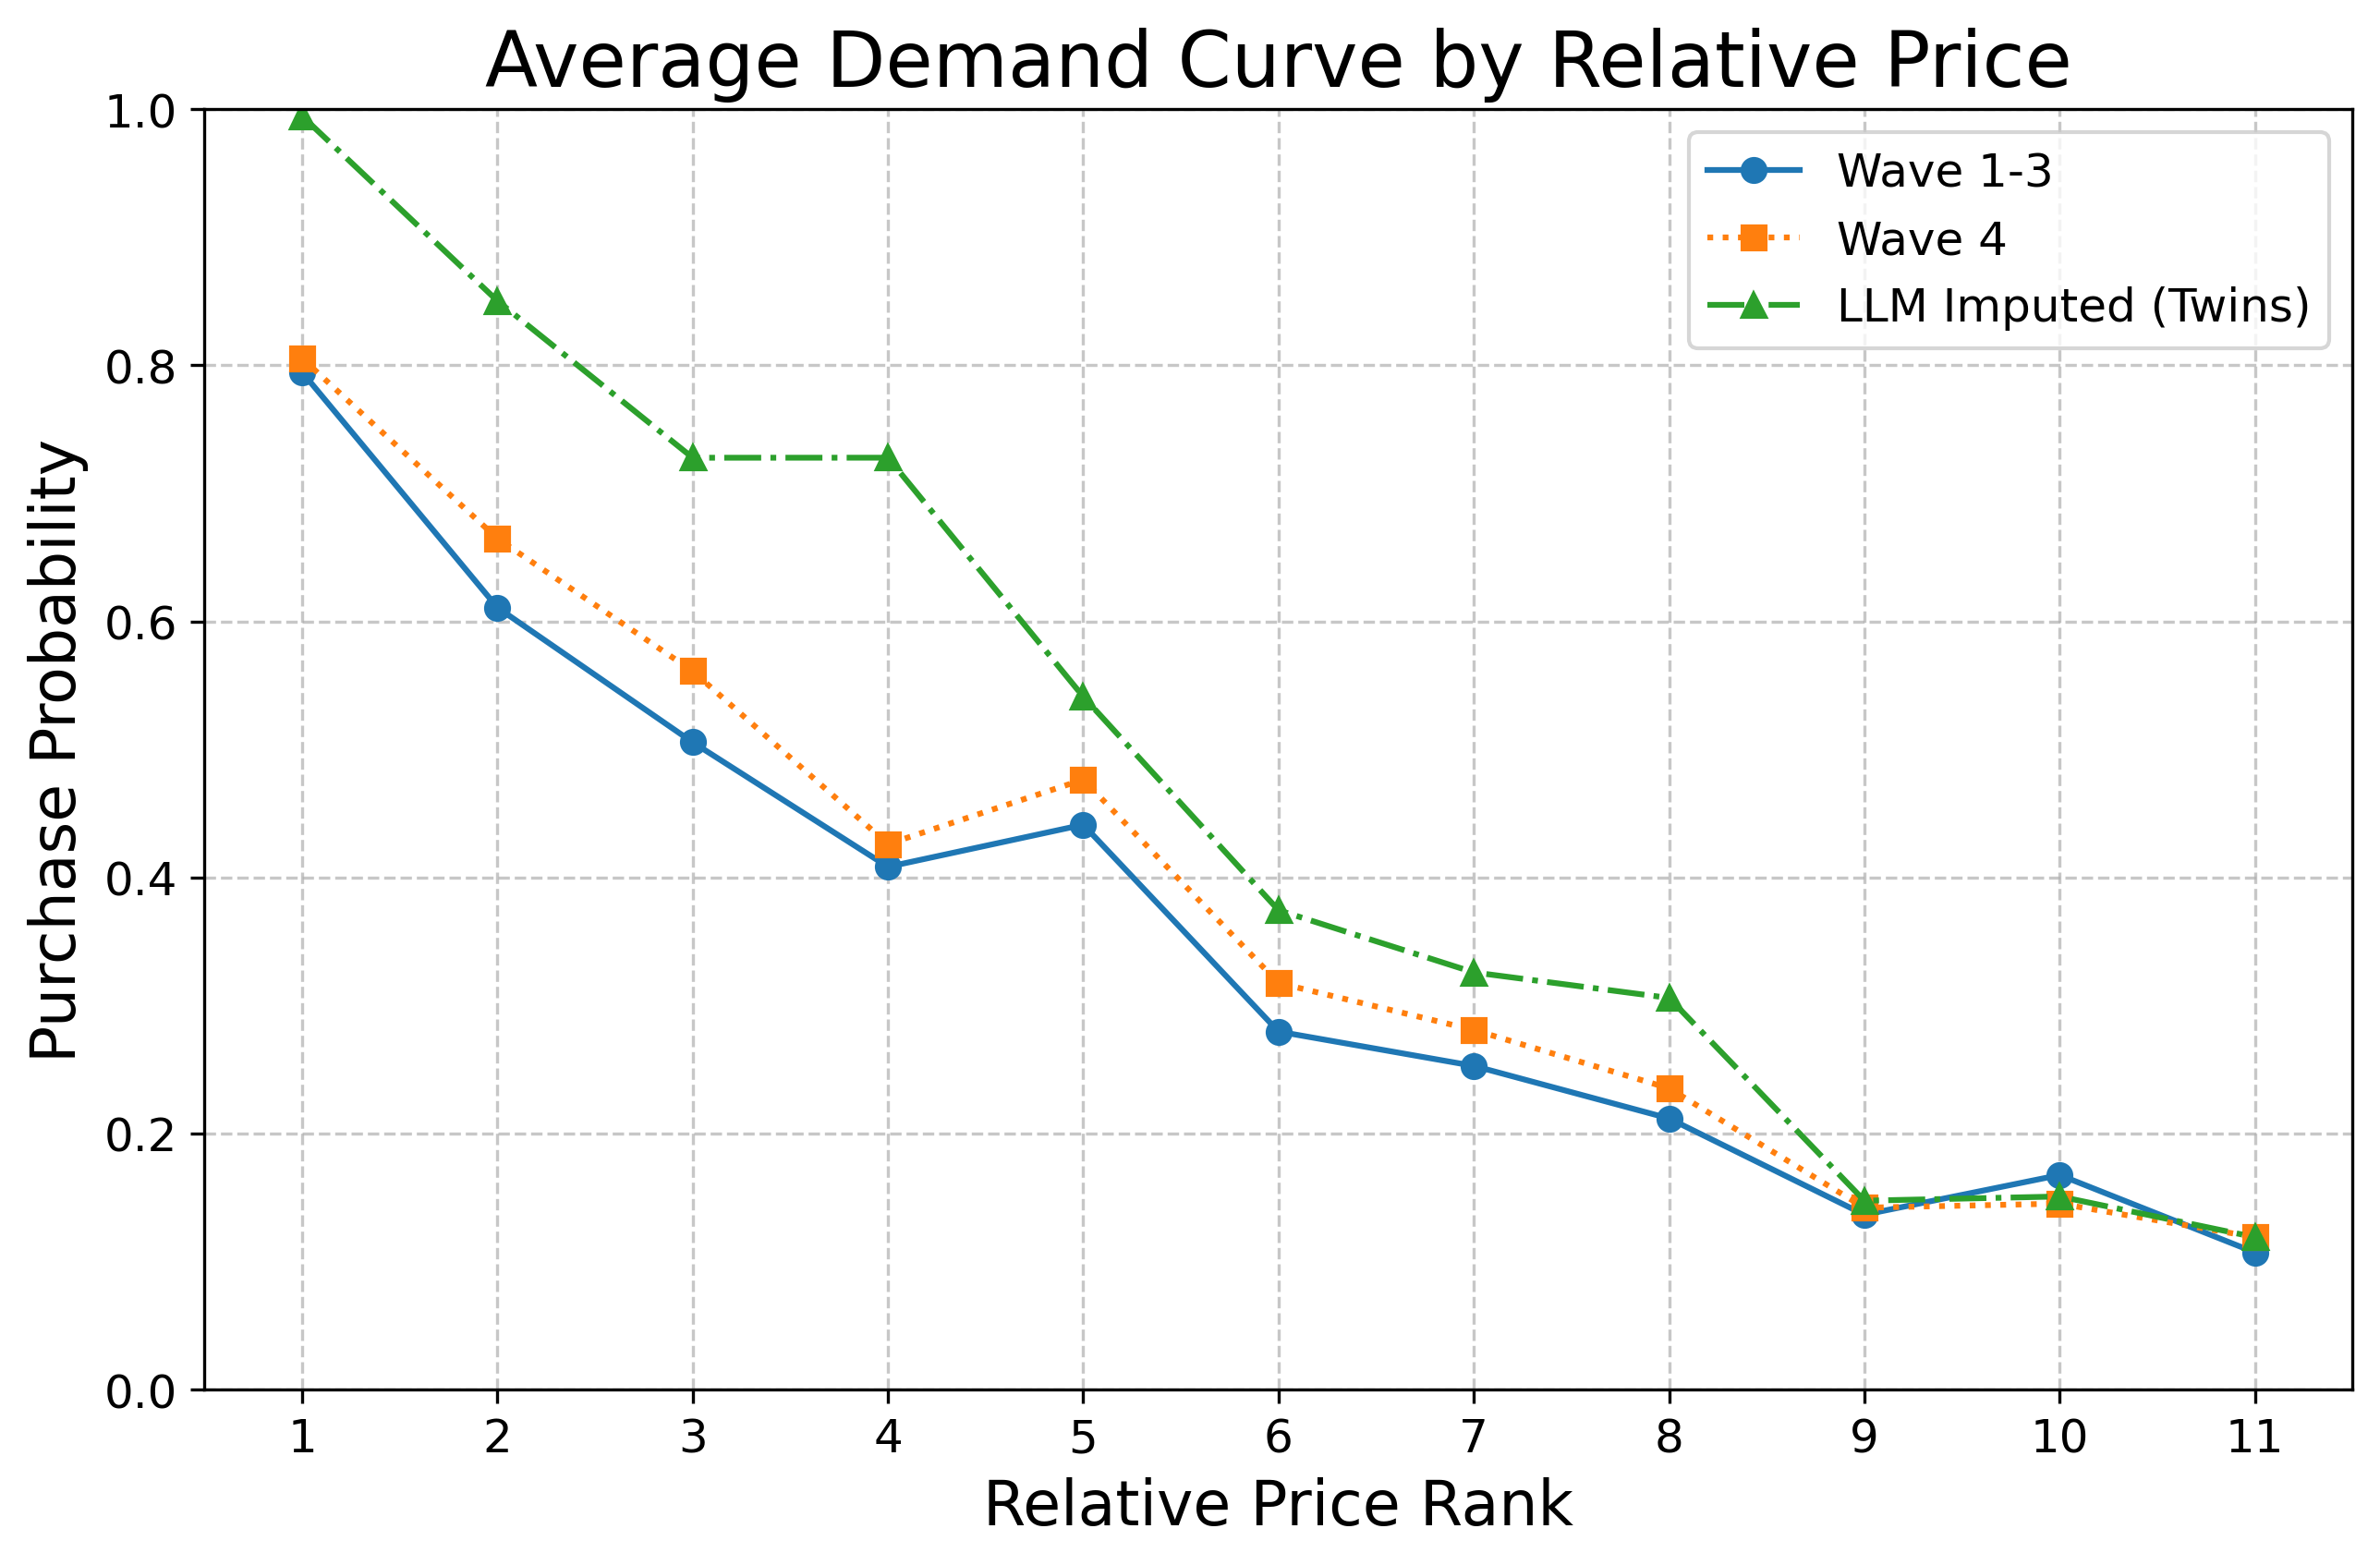

In [26]:
print("=" * 60)
print("Step 9: Pricing Analysis")
print("=" * 60)

# Import pricing analysis functions directly
from evaluation.pricing_analysis import (
    load_randdollar_breakdown,
    prepare_purchase_data,
    calculate_relative_prices
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set up paths for pricing analysis
label_dir = trial_dir / "csv_comparison" / "csv_formatted_label"
randdollar_file = trial_dir / "csv_comparison" / "randdollar_breakdown.csv"
output_plot = trial_dir / "pricing_analysis_results" / "average_demand_curve.png"
output_plot.parent.mkdir(parents=True, exist_ok=True)

print("Running pricing demand curve analysis...")

# Check if randdollar file exists
if not randdollar_file.exists():
    print(f"⚠️  Missing required file: {randdollar_file.name}")
    print("   This file is generated during JSON to CSV conversion")
    print("   Skipping pricing analysis...")
else:
    try:
        # Load the randdollar breakdown data
        print("Loading randdollar breakdown data...")
        df_randdollar_breakdown = load_randdollar_breakdown(str(randdollar_file))
        
        if df_randdollar_breakdown is None or df_randdollar_breakdown.empty:
            print("⚠️  Could not load randdollar breakdown data")
        else:
            print(f"   Loaded {len(df_randdollar_breakdown)} price observations")
            
            # Prepare purchase data for each wave
            print("Preparing purchase data for each wave...")
            data_wave3 = prepare_purchase_data(df_randdollar_breakdown, "Wave1-3")
            data_wave4 = prepare_purchase_data(df_randdollar_breakdown, "Wave4")
            data_llm = prepare_purchase_data(df_randdollar_breakdown, "LLM_Imputed")
            
            # Combine all purchase data
            all_purchase_data = pd.concat([data_wave3, data_wave4, data_llm], ignore_index=True)
            
            if all_purchase_data.empty:
                print("⚠️  No purchase data could be processed")
            else:
                print(f"   Prepared {len(all_purchase_data)} purchase observations")
                
                # Calculate relative prices
                print("Calculating relative prices...")
                all_purchase_data, nprices = calculate_relative_prices(all_purchase_data)
                
                if nprices == 0:
                    print("⚠️  Could not determine price ranks - cannot generate demand curves")
                else:
                    print(f"   Found {nprices} distinct price points")
                    
                    # Compute demand curves
                    print("Computing demand curves...")
                    demand_curves = {}
                    for wave_name in ["Wave1-3", "Wave4", "LLM_Imputed"]:
                        current_wave_data = all_purchase_data[all_purchase_data["Wave"] == wave_name]
                        if not current_wave_data.empty:
                            curve = current_wave_data.groupby("Relative_Price_Rank")["Purchase"].mean()
                            # Reindex to ensure all price ranks from 1 to nprices are present
                            demand_curves[wave_name] = curve.reindex(range(1, nprices + 1), fill_value=np.nan)
                        else:
                            demand_curves[wave_name] = pd.Series([np.nan] * nprices, index=range(1, nprices + 1))
                    
                    # Create the plot
                    print("Creating demand curve plot...")
                    plt.figure(figsize=(10, 6))
                    x_axis = np.arange(1, nprices + 1)
                    
                    # Plot each wave's demand curve
                    if not demand_curves["Wave1-3"].isna().all():
                        plt.plot(x_axis, demand_curves["Wave1-3"], linestyle='-', marker='o', label='Wave 1-3')
                    if not demand_curves["Wave4"].isna().all():
                        plt.plot(x_axis, demand_curves["Wave4"], linestyle=':', marker='s', label='Wave 4')
                    if not demand_curves["LLM_Imputed"].isna().all():
                        plt.plot(x_axis, demand_curves["LLM_Imputed"], linestyle='-.', marker='^', label='LLM Imputed (Twins)')
                    
                    plt.ylim(0, 1)
                    plt.xticks(x_axis, fontsize=12)
                    plt.yticks(fontsize=12)
                    plt.xlabel('Relative Price Rank', fontsize=16)
                    plt.ylabel('Purchase Probability', fontsize=16)
                    plt.title('Average Demand Curve by Relative Price', fontsize=20)
                    plt.legend(fontsize=12, loc='best')
                    plt.grid(True, linestyle='--', alpha=0.7)
                    
                    # Save the plot
                    plt.savefig(str(output_plot), dpi=300, bbox_inches='tight')
                    plt.close()
                    
                    print(f"✅ Pricing analysis completed successfully")
                    print(f"   Demand curve plot saved to: {output_plot.name}")
                    
                    # Try to display the plot in the notebook
                    try:
                        from IPython.display import Image, display
                        display(Image(str(output_plot)))
                    except:
                        print("   (Plot saved but cannot display inline)")
                        
    except Exception as e:
        print(f"⚠️  Pricing analysis encountered an error: {e}")
        print("   This may be due to insufficient pricing data in the limited demo")
        print("   For full analysis, use the complete dataset with all personas")